Ex uses the following command
```
python run_pipeline.py --start "2025-01-07 10:00" --end "2025-01-08 10:00"
```

In [8]:
import zarr
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
import time
import cartopy.crs as ccrs 
import cartopy.feature as cfeature
from processors.utils import normalize_lon

In [9]:
zarr_path = "data\\20250107_1000-20250108_1000_WF.zarr"

# 1. Dynamically find available fires to prevent ID KeyError
store = zarr.open_group(zarr_path, mode='r')
available_fires = list(store.group_keys())

if not available_fires:
    print("No fires found in the Zarr store!")
else:
    print(f"Fires available on disk: {available_fires}")
    
    # 2. Pick the first fire in the list (Change [0] to [1], etc. to view others)
    fire_id = available_fires[3] 

    # MUST use consolidated=False to read the appended stream correctly!
    ds = xr.open_zarr(zarr_path, group=fire_id, consolidated=False)
    fire_name = ds.attrs.get('Fire_Name', '')

fire_id

Fires available on disk: ['2025-CALAC-009087', '2025-AZSCA-000035', '2025-CALFD-0003294', '2025-CALFD-000738']


'2025-CALFD-000738'


=== Target Fire:  (2025-CALFD-000738) ===
Reported Acres: Unknown
Time steps captured: 25 hours
----------------------------------------


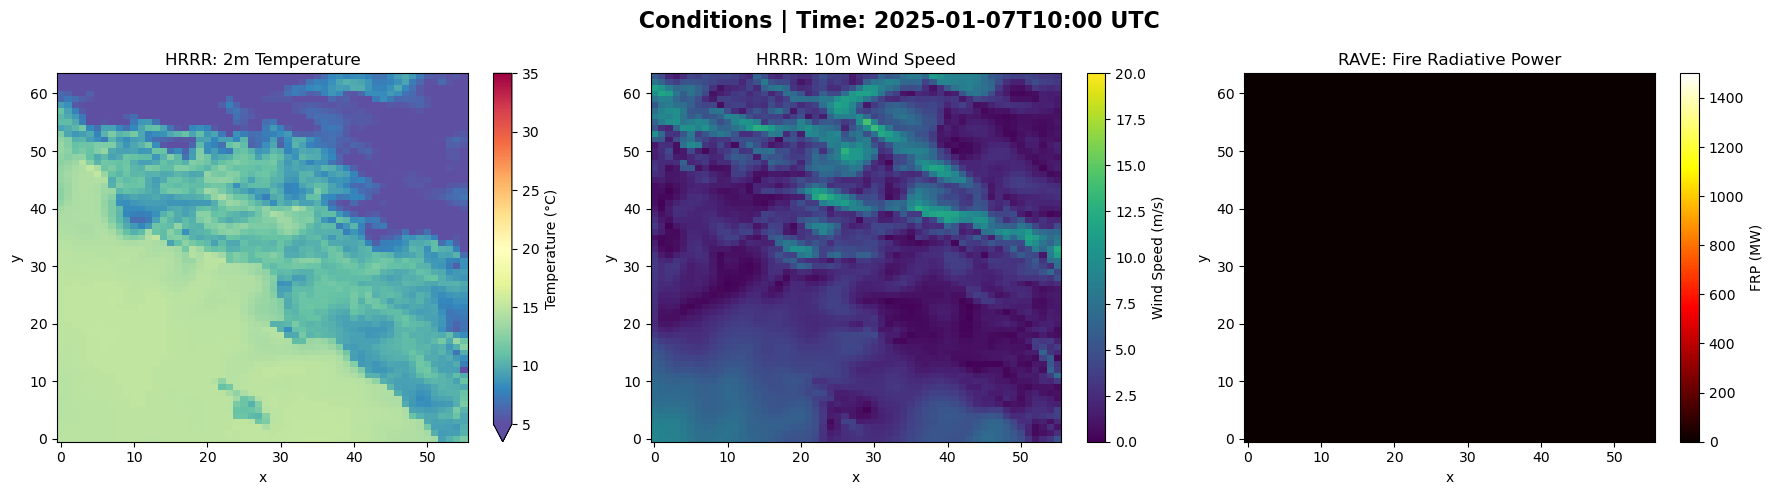

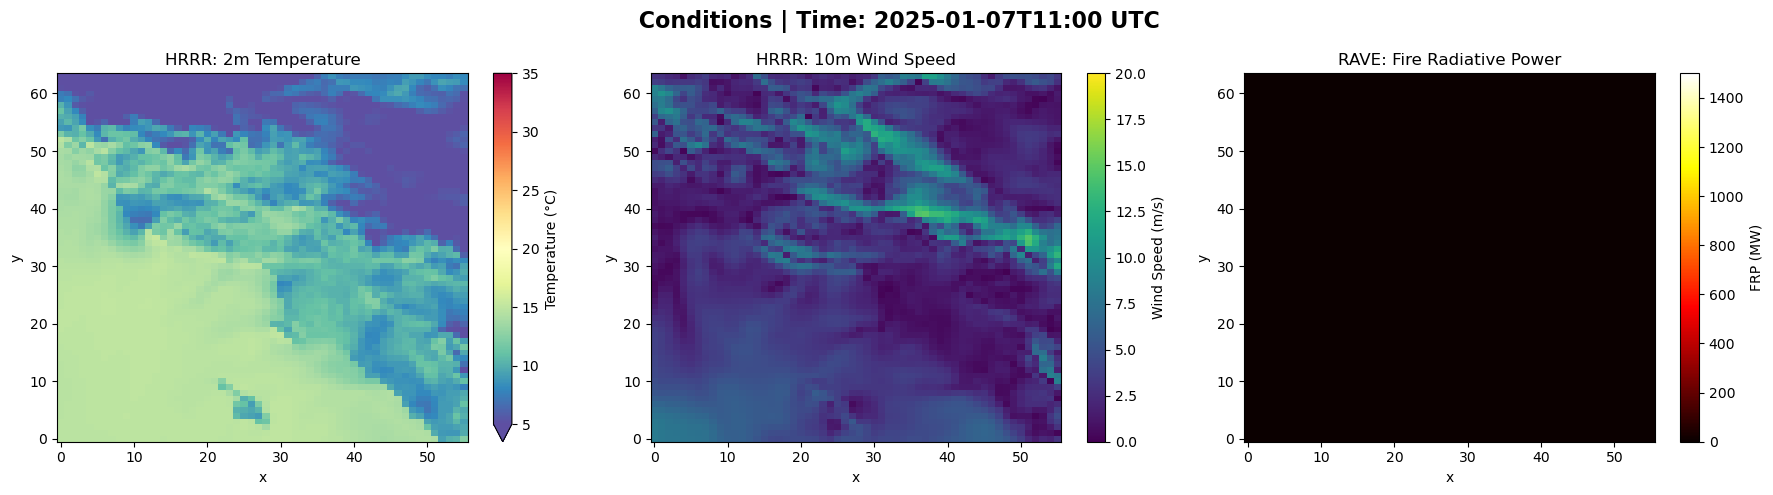

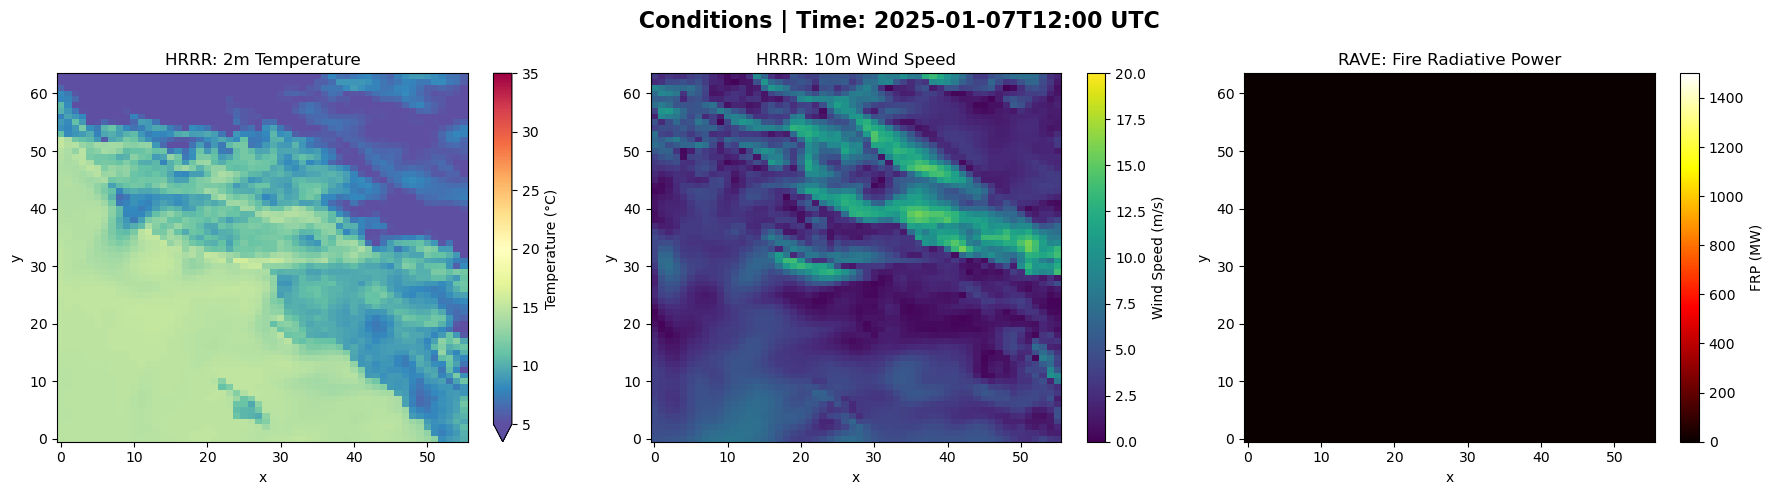

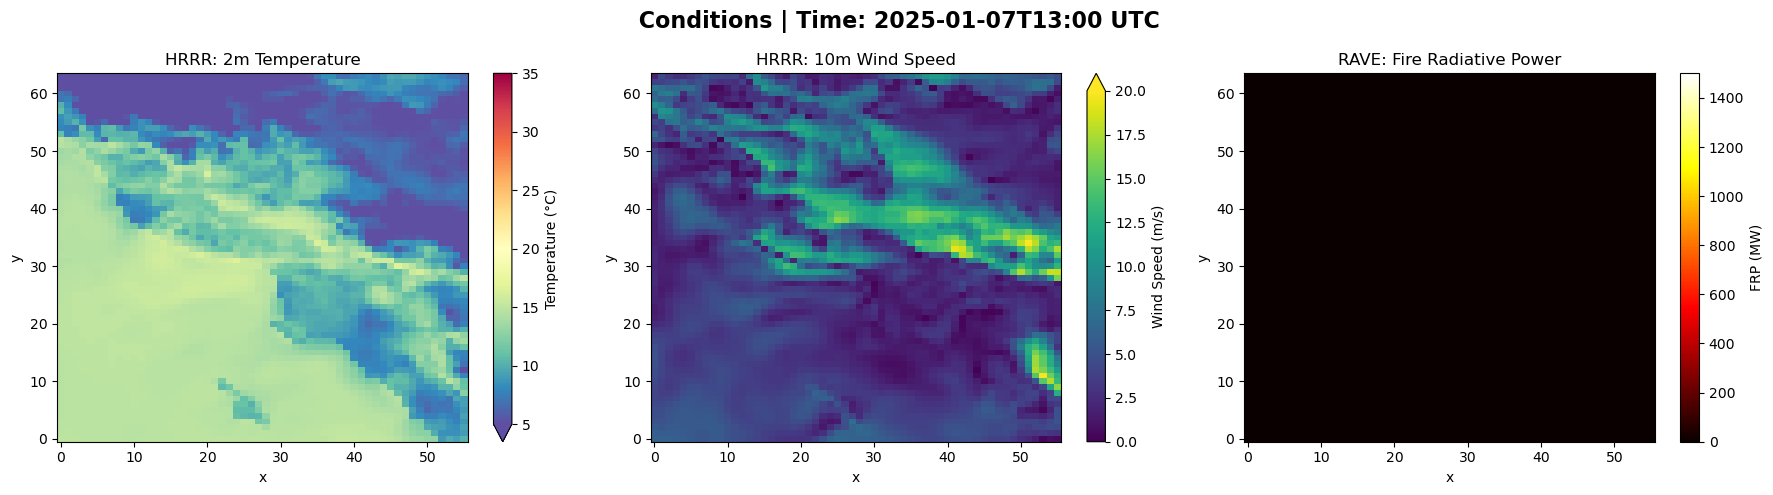

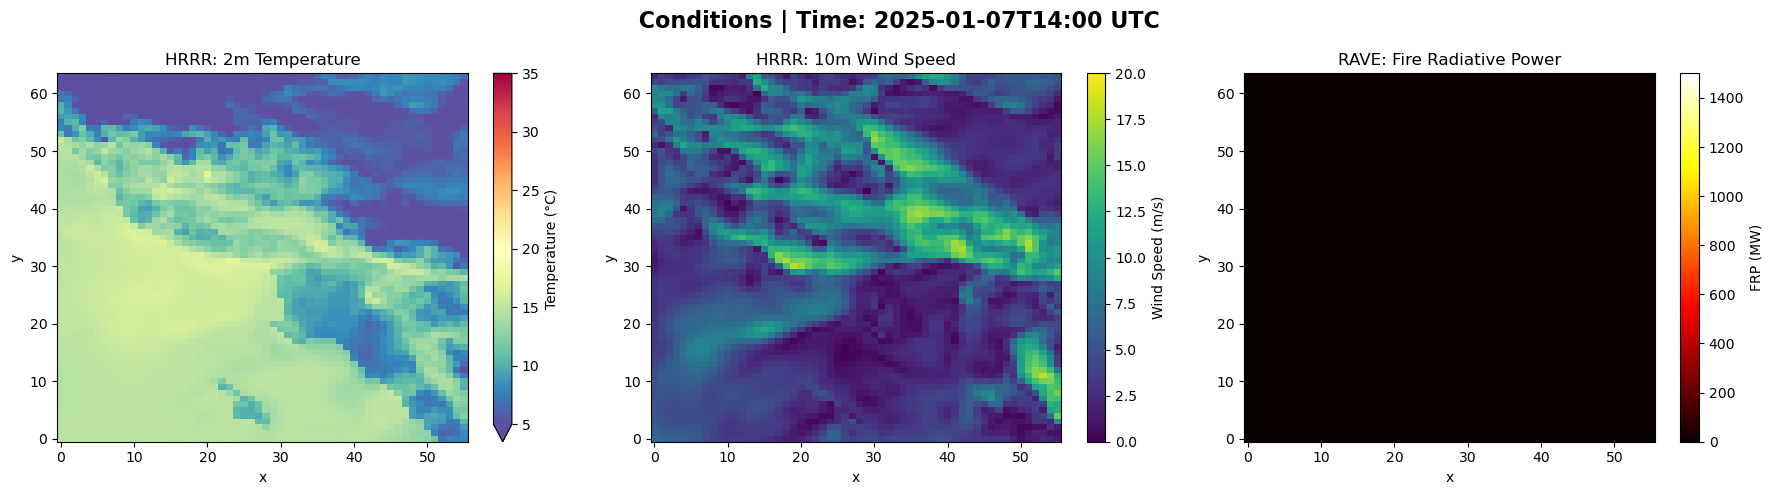

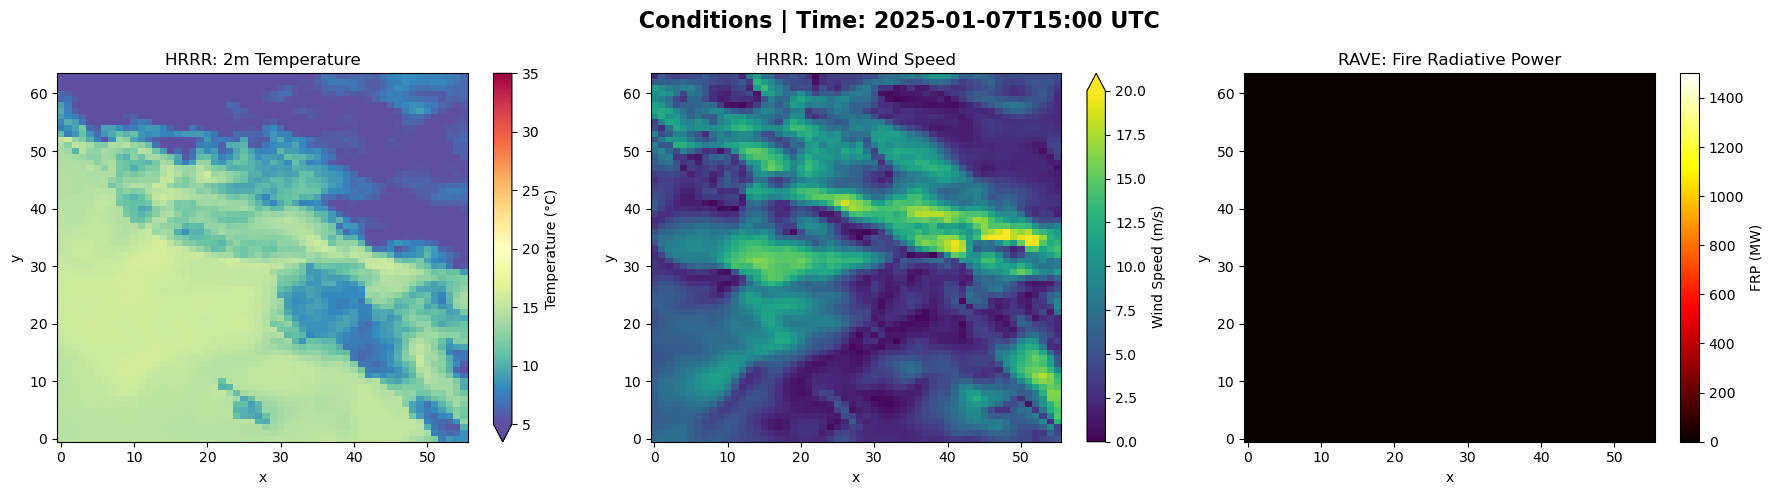

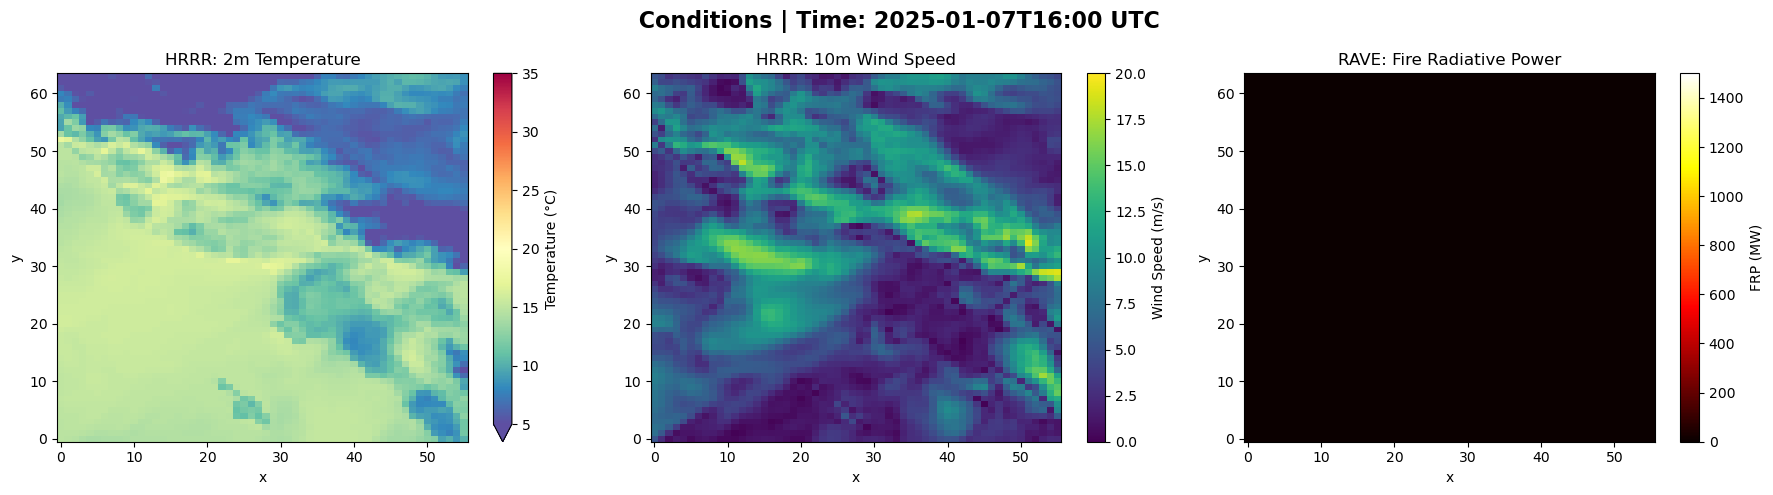

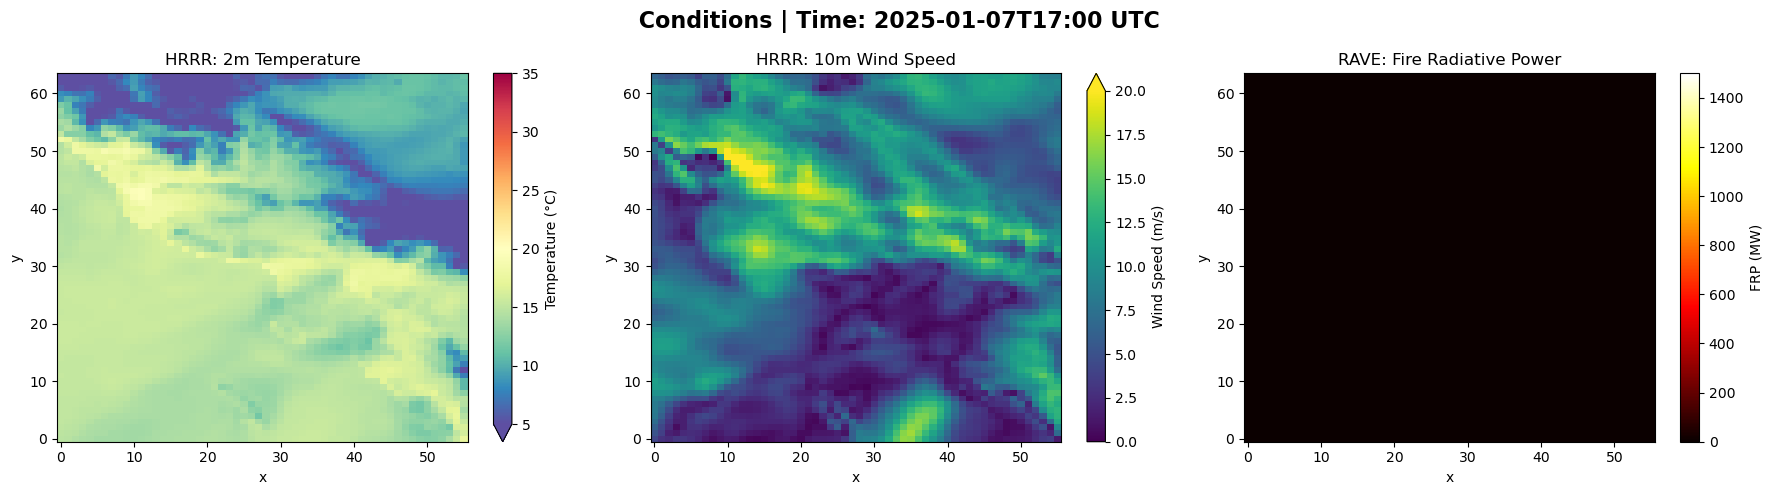

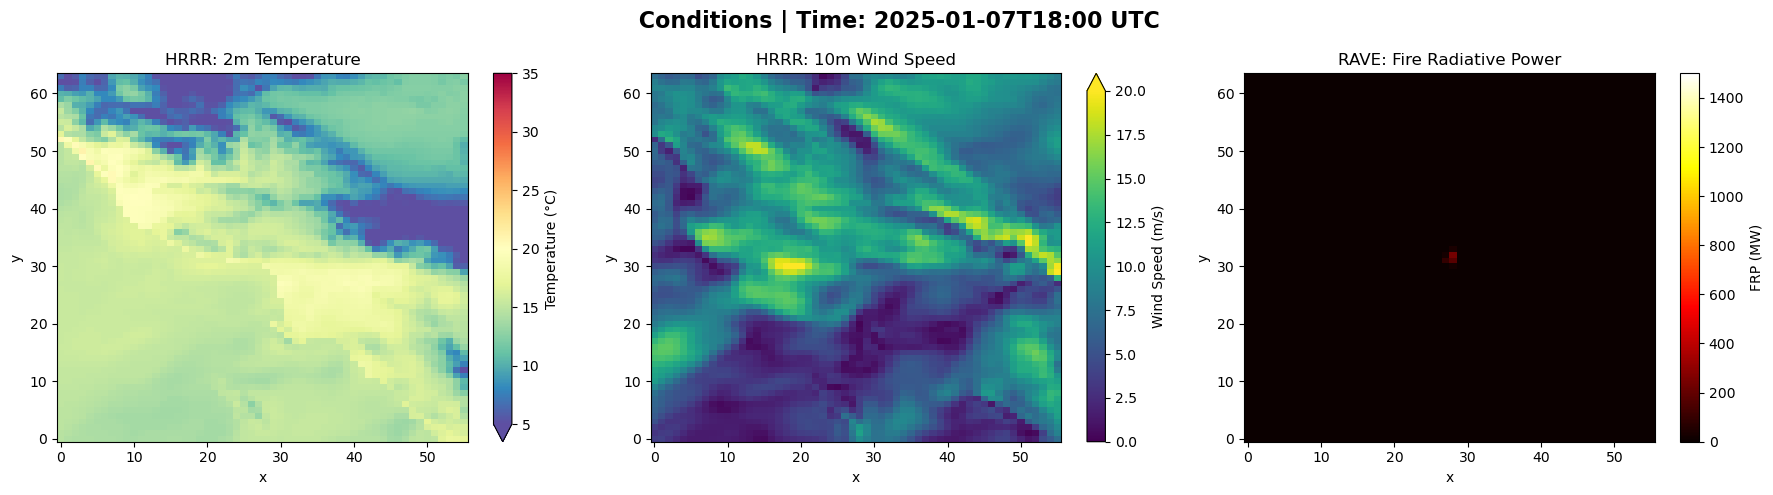

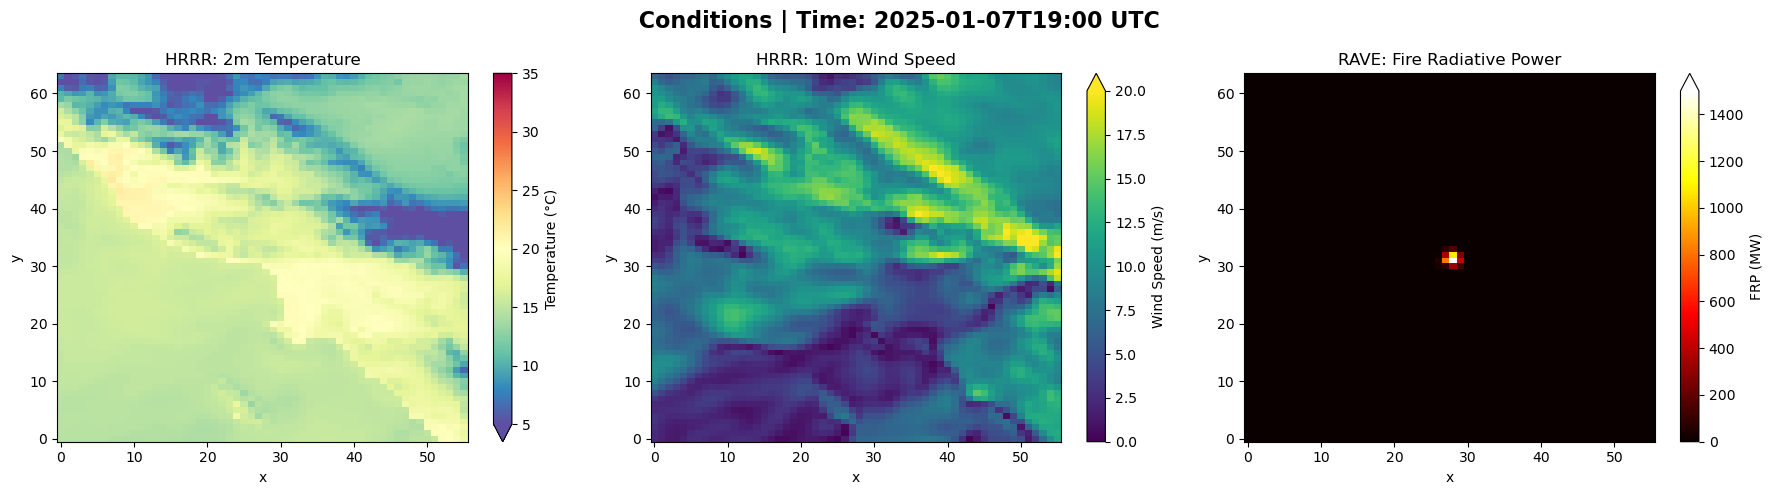

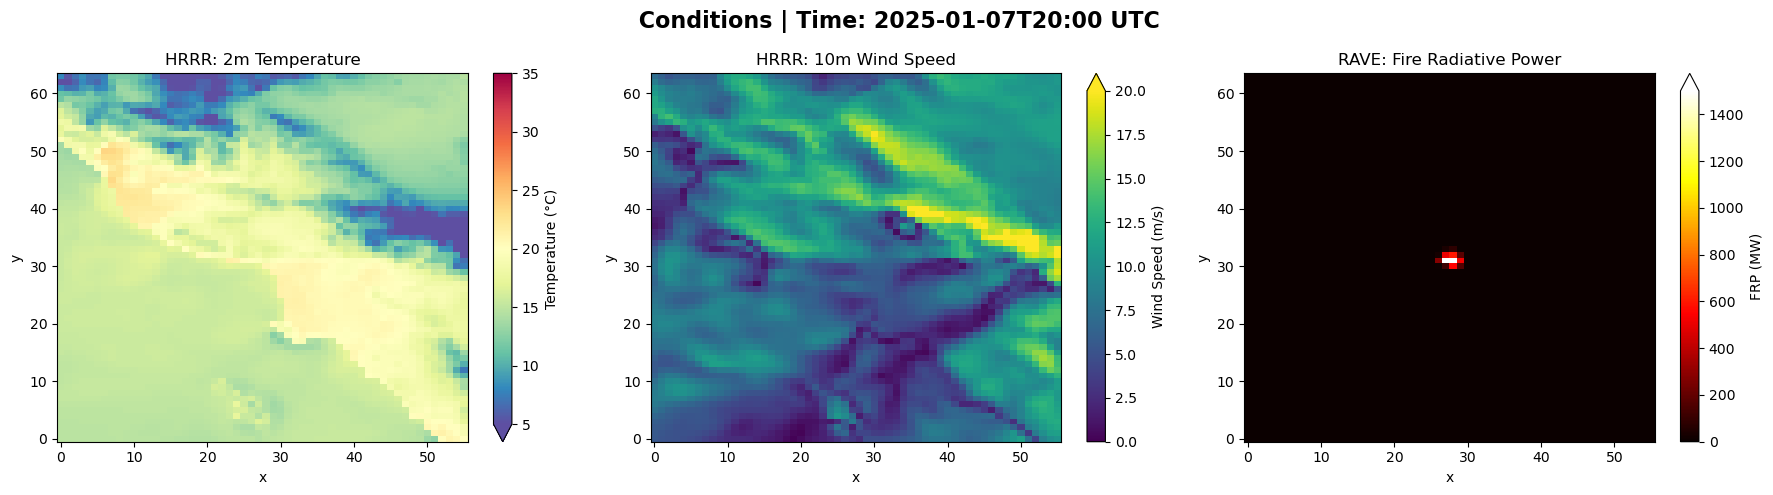

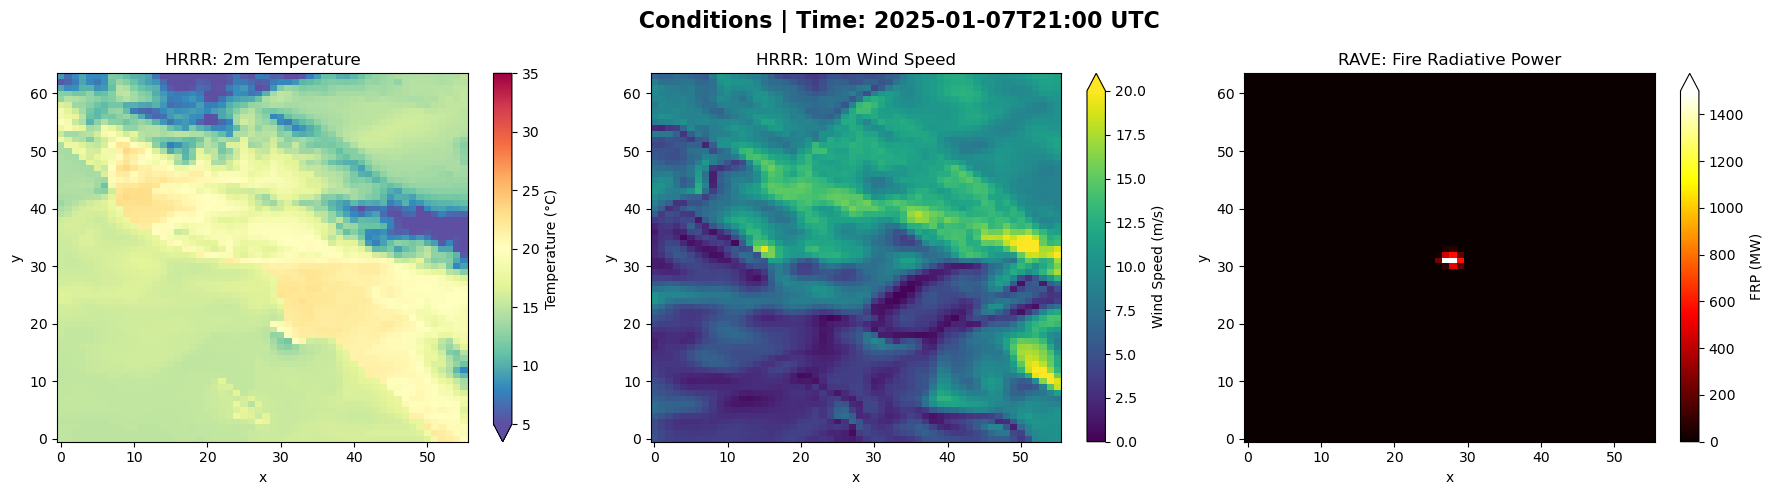

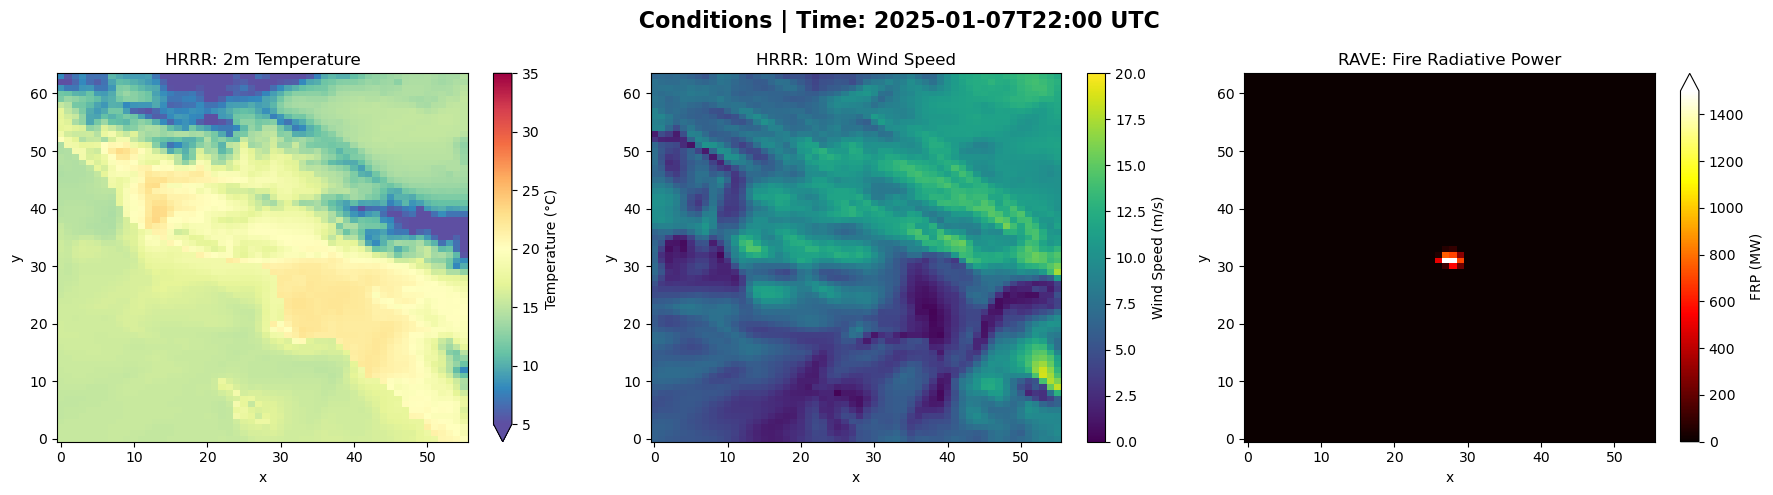

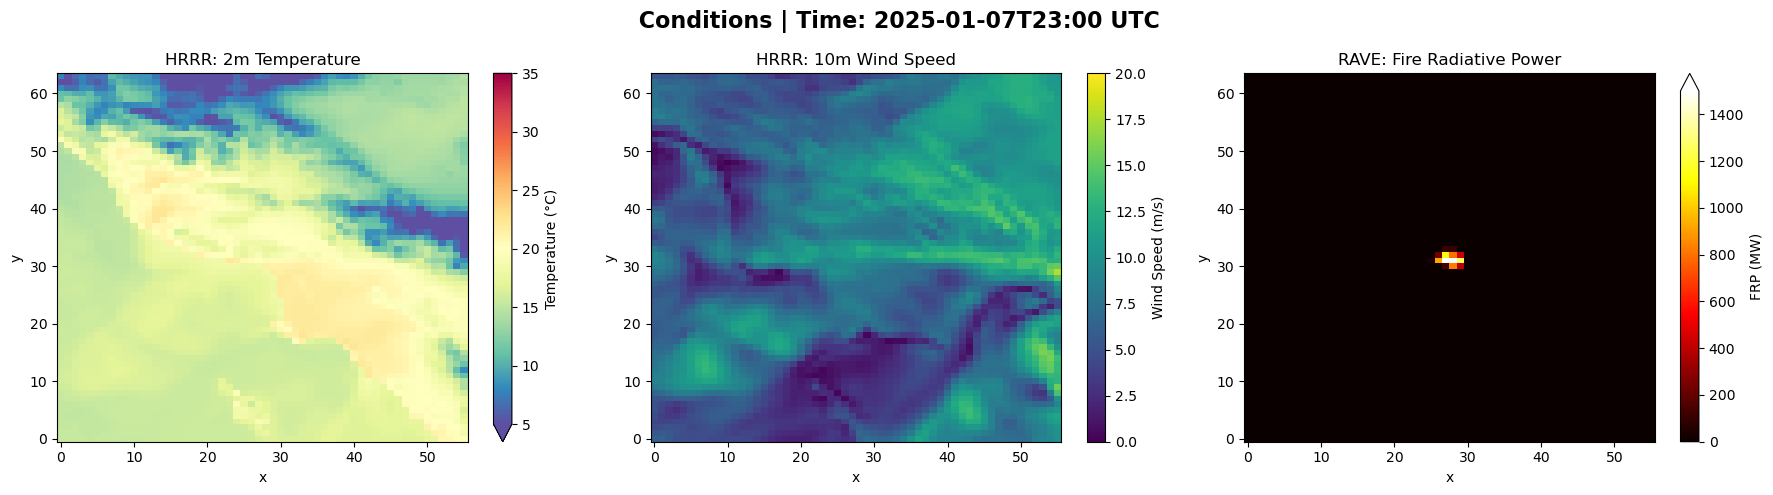

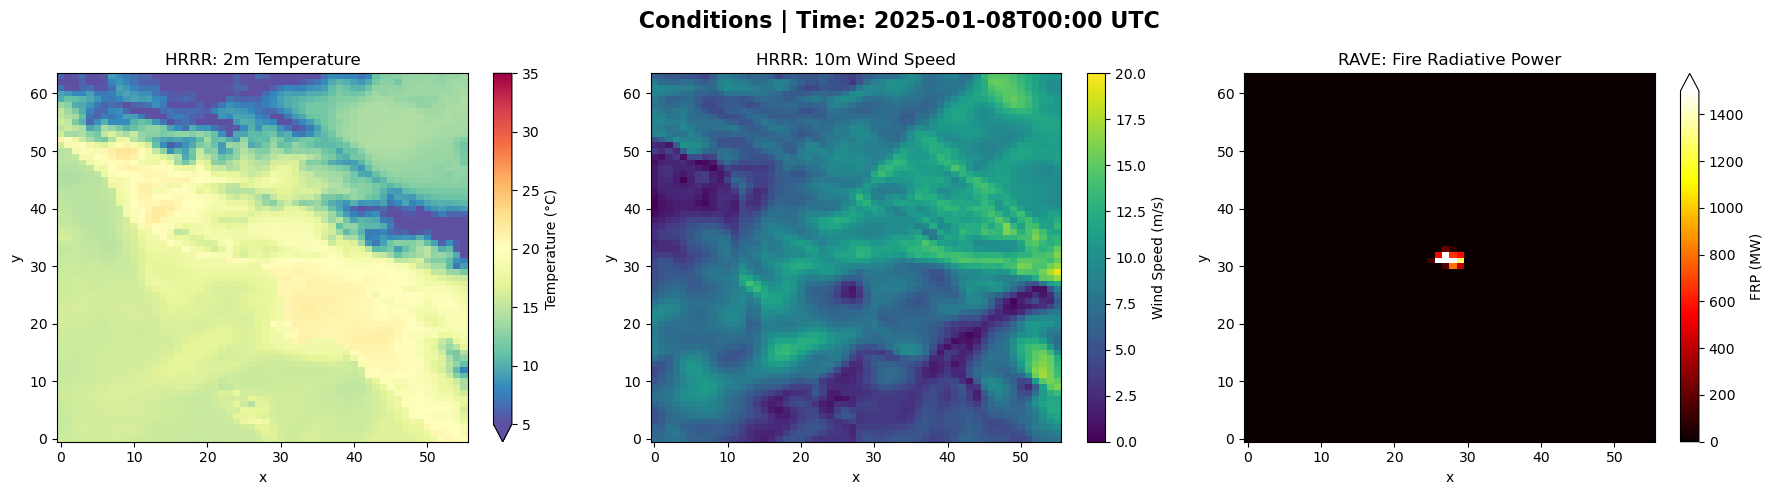

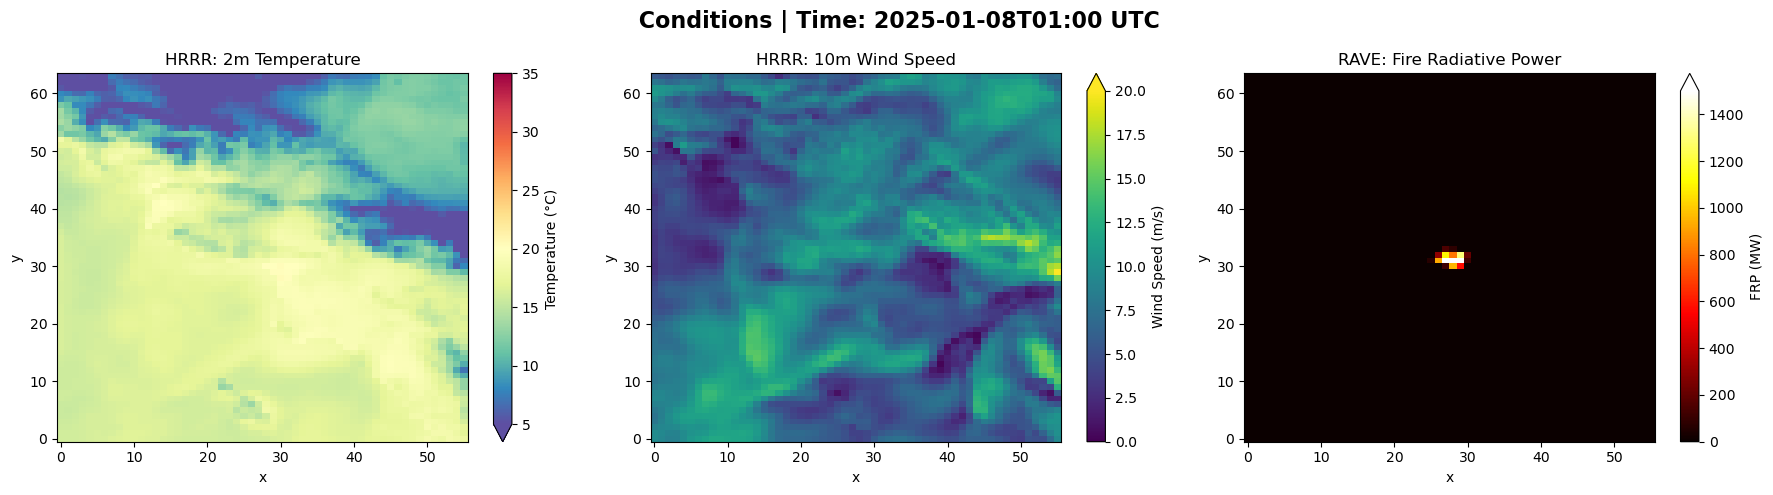

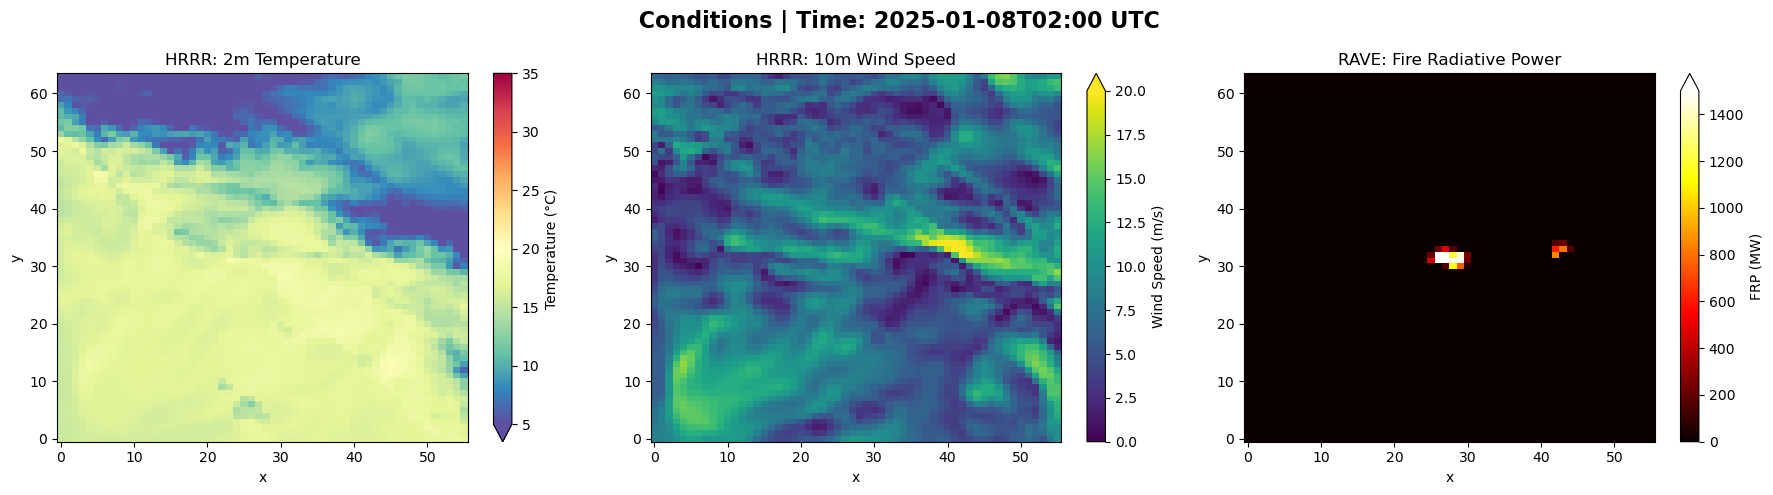

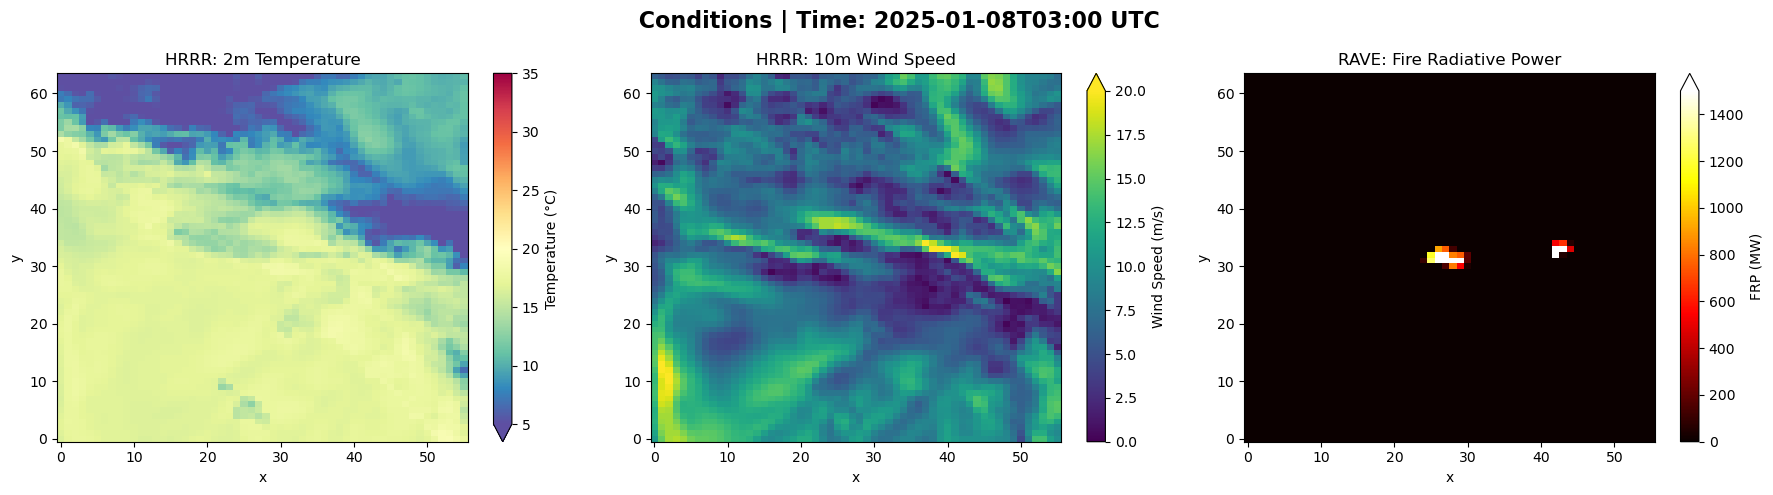

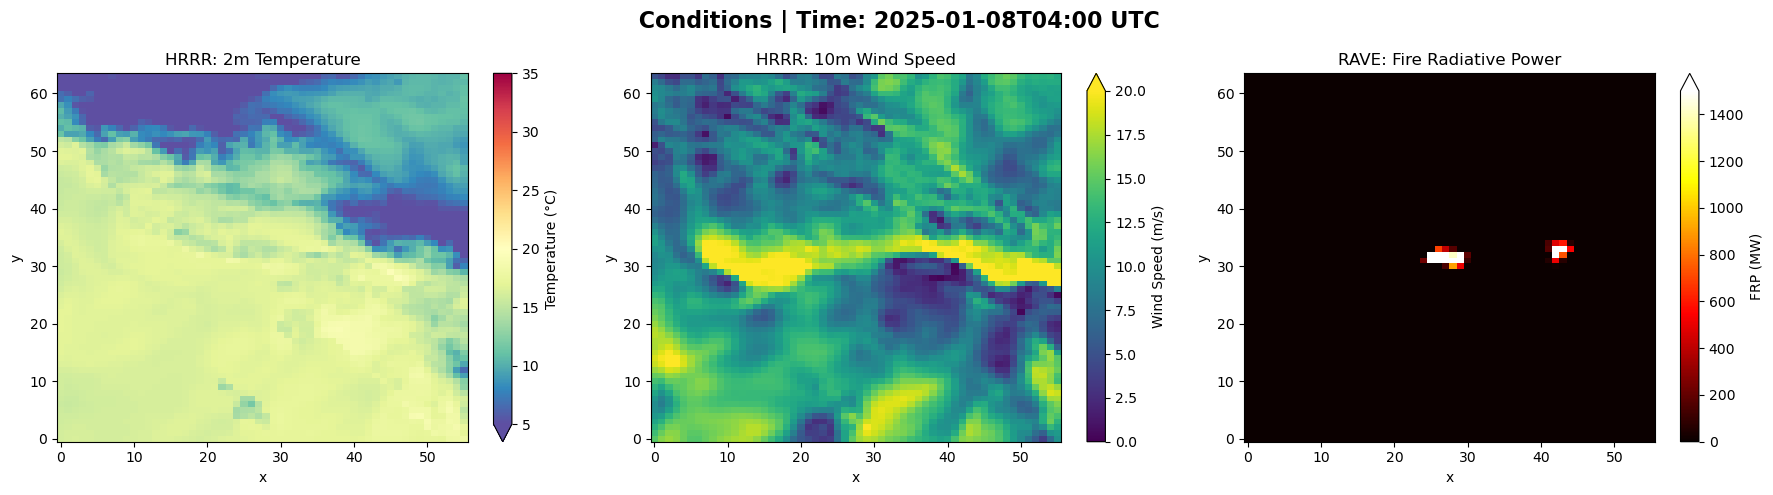

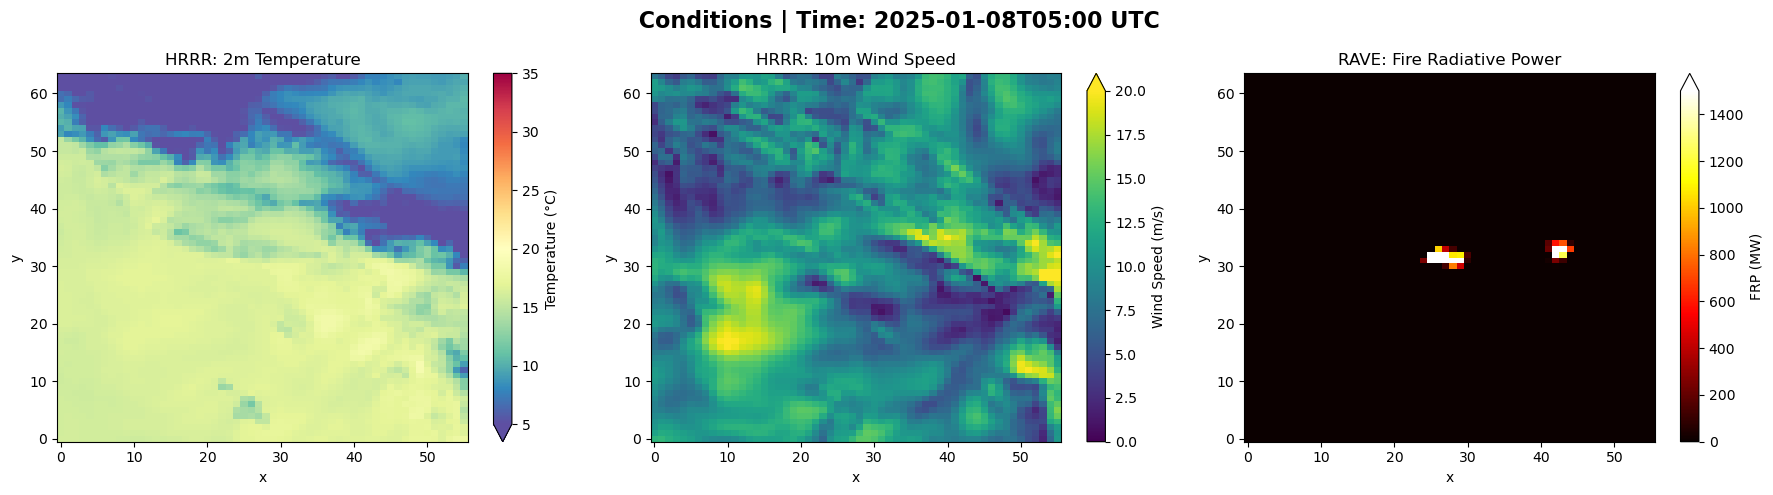

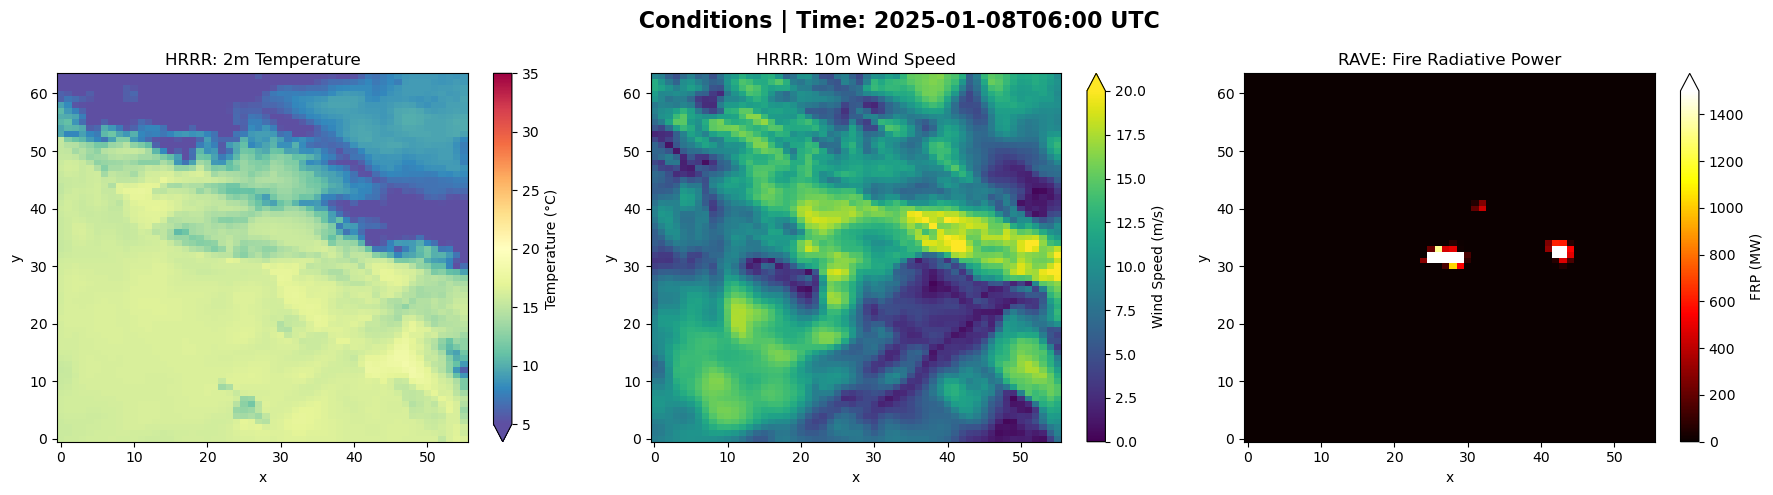

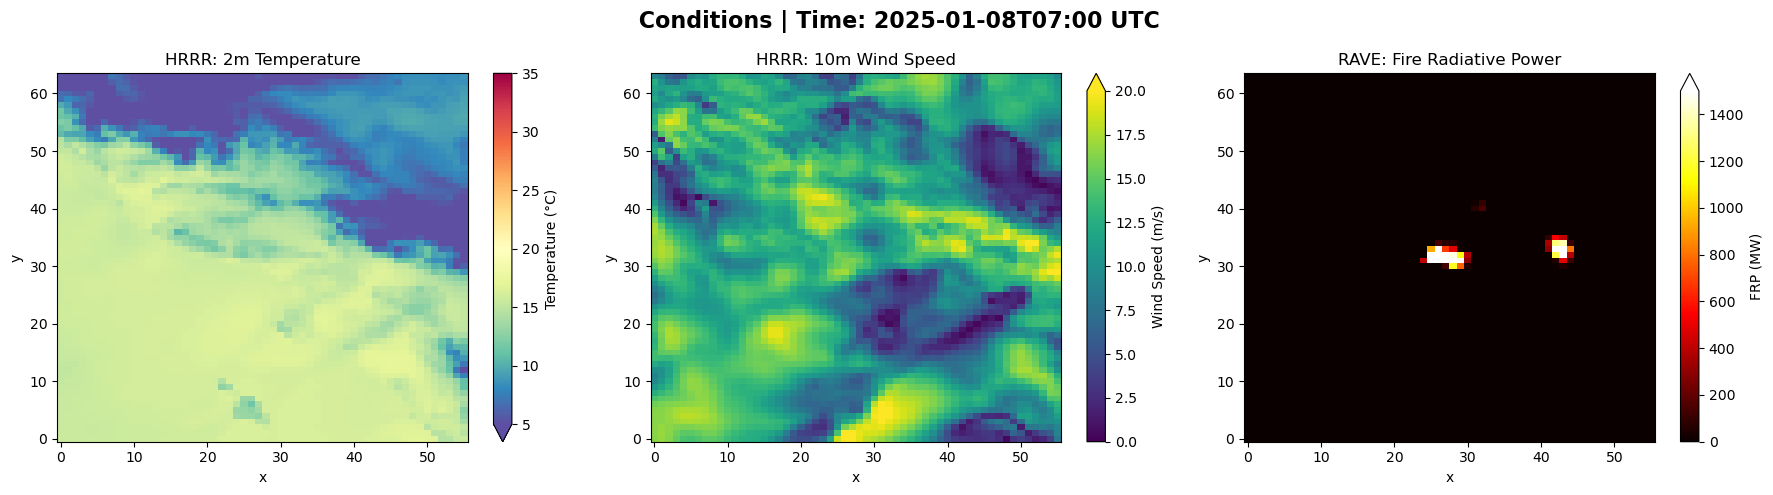

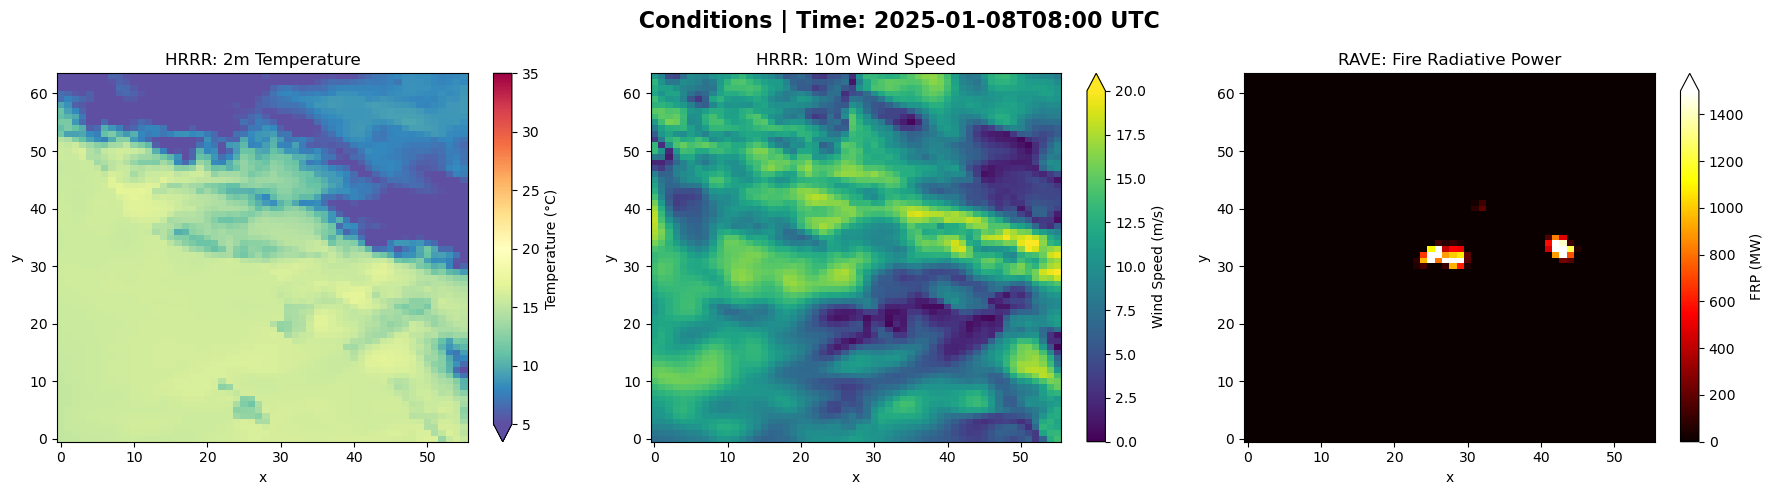

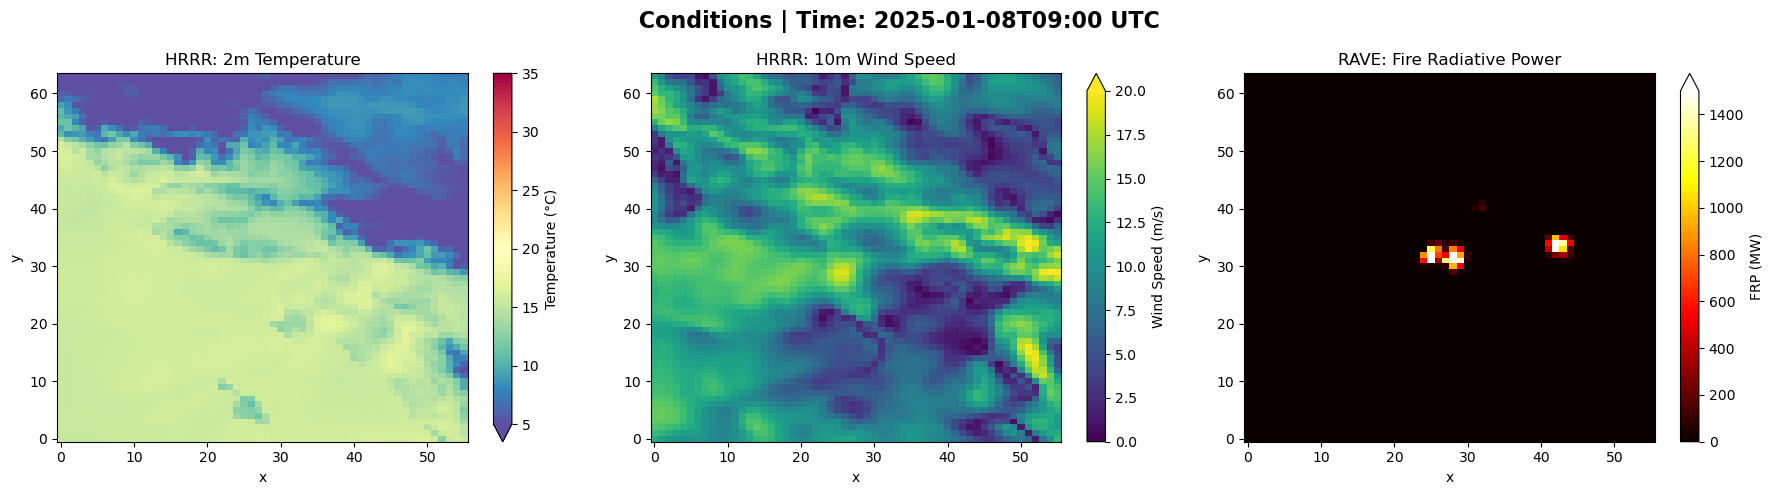

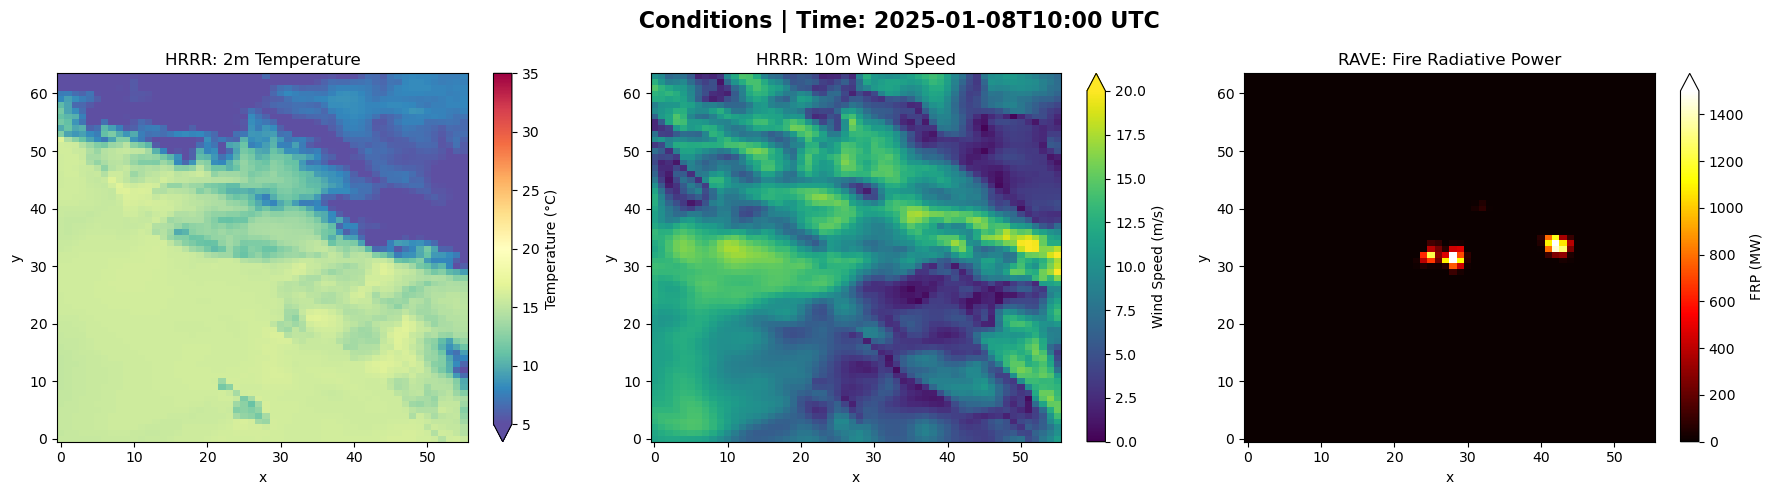

In [10]:
print(f"\n=== Target Fire: {fire_name} ({fire_id}) ===")
print(f"Reported Acres: {ds.attrs.get('Fire_Acres', 'Unknown')}")
print(f"Time steps captured: {ds.sizes['time']} hours")
print("-" * 40)

time.sleep(2) # Pause so you can read the metadata

# 3. Loop through EVERY time step for the animation
for time_idx in range(ds.sizes['time']):
    ds_hour = ds.isel(time=time_idx)
    current_time = str(ds_hour.time.values)[:16] 
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{fire_name} Conditions | Time: {current_time} UTC", fontsize=16, fontweight='bold')

    # --- PANEL 1: Temperature ---
    temp_c = ds_hour['t2m'] - 273.15
    temp_c.plot(
        ax=axes[0], cmap="Spectral_r", 
        vmin=5, vmax=35, # LOCKED SCALE: 5C to 35C 
        cbar_kwargs={'label': 'Temperature (°C)'}
    )
    axes[0].set_title("HRRR: 2m Temperature")

    # --- PANEL 2: Wind Speed ---
    wind_speed = np.sqrt(ds_hour['u10']**2 + ds_hour['v10']**2)
    wind_speed.plot(
        ax=axes[1], cmap="viridis", 
        vmin=0, vmax=20, # LOCKED SCALE: 0 to 20 m/s
        cbar_kwargs={'label': 'Wind Speed (m/s)'}
    )
    axes[1].set_title("HRRR: 10m Wind Speed")

    # --- PANEL 3: Fire Radiative Power ---
    ds_hour['rave_frp'].plot(
        ax=axes[2], cmap="hot", 
        vmax=1500, vmin=0, # LOCKED SCALE for FRP
        cbar_kwargs={'label': 'FRP (MW)'}
    )
    axes[2].set_title("RAVE: Fire Radiative Power")

    plt.tight_layout()
    plt.show()
    
    # Clear the output for the next frame
    # time.sleep(0.5)
    # clear_output(wait=True)

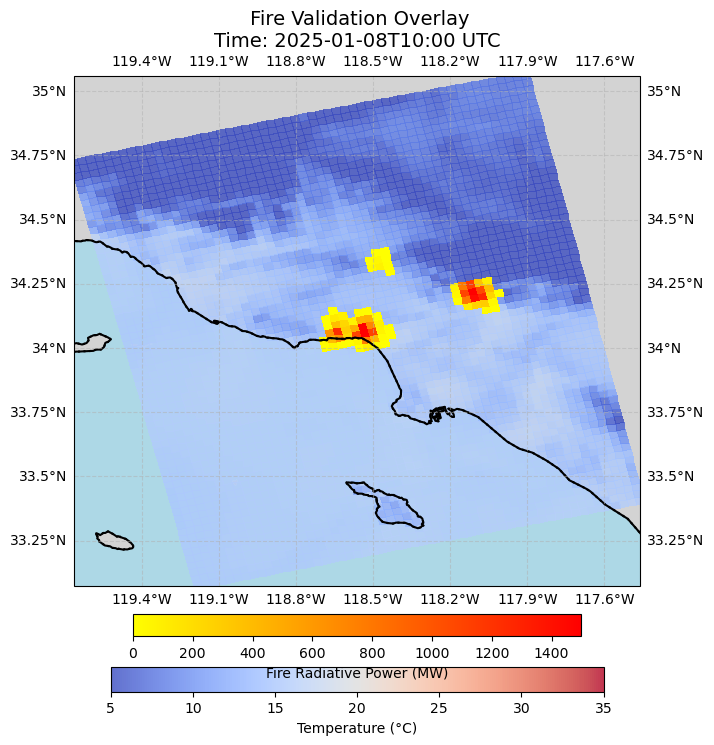

In [11]:
print(f"\n=== Target Fire: {fire_name} ({fire_id}) ===")
print(f"Reported Acres: {ds.attrs.get('Fire_Acres', 'Unknown')}")
print(f"Time steps captured: {ds.sizes['time']} hours")
print("-" * 40)

ds_plot = normalize_lon(ds)

lon_min, lon_max = float(ds_plot.lon.min()), float(ds_plot.lon.max())
lat_min, lat_max = float(ds_plot.lat.min()), float(ds_plot.lat.max())

for time_idx in range(ds_plot.sizes['time']):
    ds_t = ds_plot.isel(time=time_idx)

    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # --- NEW: Added State borders ---
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=1.5)
    ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=1.5)
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=1.5, linestyle=':') # Dotted State Lines
    ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

    # Plot HRRR Temperature (t2m)
    temp_c = ds_t.t2m - 273.15
    temp_plot = ax.pcolormesh(
        ds_t.lon, ds_t.lat, temp_c,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        alpha=0.8,
        shading='auto',
        vmin=5, vmax=35 
    )

    # Plot RAVE Fire (FRP) on top 
    frp_masked = ds_t.rave_frp.where(ds_t.rave_frp > 0)
    fire_plot = ax.pcolormesh(
        ds_t.lon, ds_t.lat, frp_masked,
        transform=ccrs.PlateCarree(),
        cmap='autumn_r',
        vmin=0, vmax=1500, 
        shading='auto'
    )

    # Add colorbars
    plt.colorbar(temp_plot, label='Temperature (°C)', ax=ax, orientation='horizontal', pad=0.05, fraction=0.04)
    plt.colorbar(fire_plot, label='Fire Radiative Power (MW)', ax=ax, orientation='horizontal', pad=0.05, fraction=0.04)

    ax.set_extent([lon_min, lon_max, lat_min, lat_max])

    plt.title(f"{fire_name} Fire Validation Overlay\nTime: {str(ds_t.time.values)[:16]} UTC", fontsize=14)
    plt.show()
    
    # Animate
    time.sleep(0.5)
    clear_output(wait=True)

In [ ]:
import xarray as xr
import zarr
import pandas as pd

# Path to your output data
zarr_path = "data/all_fires_combined.zarr"

try:
    # 1. Open the root of the Zarr store to see all groups (fire IDs)
    root = zarr.open(zarr_path, mode='r')
    fire_ids = list(root.group_keys())
    
    print(f"--- Zarr Inspection: {len(fire_ids)} fires found ---\n")

    for fire_id in fire_ids:
        # 2. Open each fire group as an xarray dataset
        ds = xr.open_zarr(zarr_path, group=fire_id, consolidated=False)
        
        # 3. Extract time information
        times = pd.to_datetime(ds.time.values)
        start_captured = times.min()
        end_captured = times.max()
        duration_hours = len(times)
        
        # 4. Extract spatial information (to verify spatial_pad)
        lat_range = (ds.lat.values.min(), ds.lat.values.max())
        lon_range = (ds.lon.values.min(), ds.lon.values.max())

        print(f"Fire ID: {fire_id}")
        print(f"  Name: {ds.attrs.get('Fire_Name', 'N/A')}")
        print(f"  Acres: {ds.attrs.get('Fire_Acres', 'N/A')}")
        print(f"  Captured Range: {start_captured} to {end_captured} ({duration_hours} hours)")
        print(f"  BBox (Lat): {lat_range[0]:.4f} to {lat_range[1]:.4f}")
        print(f"  BBox (Lon): {lon_range[0]:.4f} to {lon_range[1]:.4f}")
        print("-" * 40)

except Exception as e:
    print(f"Error inspecting Zarr: {e}")